<a href="https://colab.research.google.com/github/fadwamerzak/CRUD_Operation_with_Laravel/blob/master/Orange_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DistilBERT Classifier

DistilBERT is a lighter transformer model of the original BERT model

## Data Processing

In [ ]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from transformers import DistilBertTokenizer
from transformers import TFDistilBertForSequenceClassification

In [ ]:
df = pd.read_csv("/content/blooms_taxonomy_dataset.csv")
# Check for missing values
print("Missing values:\n", df.isnull().sum())
df.info()
df.head()


Missing values:
 Questions    0
Category     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8767 entries, 0 to 8766
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Questions  8767 non-null   object
 1   Category   8767 non-null   object
dtypes: object(2)
memory usage: 137.1+ KB


,Questions,Category
0,About what proportion of the population of the...,BT1
1,Correctly label the brain lobes indicated on t...,BT1
2,Define compound interest.,BT1
3,Define four types of traceability,BT1
4,Define mercantilism.,BT1


In [ ]:
# removes all punctuations and change to lower case
df['Questions'] = df['Questions'].str.replace(r'[^\w\s]+', '', regex=True)
df['Questions'] = df['Questions'].str.lower()

# encode categories into numbers
# Analyse - 0
# Apply - 1
# Create - 2
# Evaluate - 3
# Remember - 4
# Understand - 5

df["Category"] = pd.factorize(df.Category)[0]

# Blooms taxonomy categories
categories = ['Analyse', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']

In [ ]:
df['Category'].value_counts()
df.head()

,Questions,Category
0,About what proportion of the population of the...,BT1
1,Correctly label the brain lobes indicated on t...,BT1
2,Define compound interest.,BT1
3,Define four types of traceability,BT1
4,Define mercantilism.,BT1


In [ ]:
# Split into Train and Validation data
train, val = train_test_split(df, test_size=0.2, random_state=0)

::## NLPAug to augment text data for Oversampling (Optional)

For this model, this is **not used** as it generates too much noise

In [ ]:
!pip install nlpaug


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 17.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import nlpaug.augmenter.word as naw
from tqdm import tqdm


def augment_sentence(sentence, aug):
    """
    Constructs a new sentence via text augmentation.

    Input:
        - sentence:     A string of text
        - aug:          An augmentation object defined by the nlpaug library

    Output:
        - A string of text that has been augmented
    """
    return aug.augment(sentence)[0]


def augment_data(df, aug, target_count):
    """
    Takes a pandas DataFrame and augments its text data to a target count.

    Input:
        - df:            A pandas DataFrame
        - aug:           Augmentation object defined by the nlpaug library.
        - target_count:  Integer representing the number of times to augment text to match count.

    Output:
        - df:            Copy of the same pandas DataFrame with augmented data
                         appended to it and with rows randomly shuffled.
    """
    for category in tqdm(df['Category'].unique()):
        # Gets the existing data
        existing_text = df[df['Category'] == category]

        # Number of extra augmented data to be generated
        num_to_gen = target_count - len(existing_text)

        # Skip if the target count is already reached
        if num_to_gen <= 0:
            continue

        # Randomly select required number of questions for augmentation
        data_to_aug = existing_text.sample(n=num_to_gen, replace=True)

        # Augment the data
        data_to_aug['Questions'] = data_to_aug['Questions'].apply(lambda x: augment_sentence(x, aug))

        # Append the augmented data to the original DataFrame
        df = df.append(data_to_aug, ignore_index=True)

    # Shuffle samples and return
    return df.sample(frac=1, random_state=0)


ModuleNotFoundError: No module named 'nlpaug'

In [ ]:
import nlpaug.augmenter.word as naw
# Use wordnet to replace words with synonyms
aug = naw.SynonymAug(aug_src='wordnet',aug_max=3)

# get label with the highest count from training set
max_count = max(list(train['Category'].value_counts()))

# augment all training datasets to max_count
#balanced__train = augment_data(train, aug, target_count=max_count)

# skip augmenting step
balanced__train = train

In [ ]:
balanced__train['Category'].value_counts()

,count
Category,
0,2056
1,1461
2,1205
3,1017
4,643
5,631


In [ ]:
df["Category"].value_counts()
df.head()

,Questions,Category
0,about what proportion of the population of the...,0
1,correctly label the brain lobes indicated on t...,0
2,define compound interest,0
3,define four types of traceability,0
4,define mercantilism,0


## Tokenizing data into BERT input format

In [ ]:
train_texts = list(df['Questions'])
train_labels = list(df['Category'])

val_texts = list(val['Questions'])
val_labels = list(val['Category'])

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

# Model Building

In [ ]:
# Model Params

LEARNING_RATE = 0.000001
BATCH_SIZE = 24
EPOCHS = 50

In [ ]:
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6)

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

## Training the Model

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

history = model.fit(train_dataset.batch(BATCH_SIZE), epochs=EPOCHS, batch_size=BATCH_SIZE,
          validation_data=val_dataset.batch(BATCH_SIZE), shuffle=True, callbacks=[callback])

# EPOCH 40: loss: 0.0773 - accuracy: 0.9820 - val_loss: 0.3031 - val_accuracy: 0.9109

Epoch 1/50
366/366 [==============================] - 112s 232ms/step - loss: 1.7616 - accuracy: 0.2676 - val_loss: 1.6557 - val_accuracy: 0.3472
Epoch 2/50
366/366 [==============================] - 83s 226ms/step - loss: 1.6178 - accuracy: 0.3509 - val_loss: 1.5469 - val_accuracy: 0.4304
Epoch 3/50
366/366 [==============================] - 83s 226ms/step - loss: 1.5041 - accuracy: 0.4258 - val_loss: 1.4122 - val_accuracy: 0.5610
Epoch 4/50
366/366 [==============================] - 83s 228ms/step - loss: 1.3794 - accuracy: 0.5283 - val_loss: 1.2724 - val_accuracy: 0.6260
Epoch 5/50
366/366 [==============================] - 84s 229ms/step - loss: 1.2656 - accuracy: 0.6009 - val_loss: 1.1562 - val_accuracy: 0.6619
Epoch 6/50
366/366 [==============================] - 83s 226ms/step - loss: 1.1694 - accuracy: 0.6343 - val_loss: 1.0643 - val_accuracy: 0.6842
Epoch 7/50
366/366 [==============================] - 83s 226ms/step - loss: 1.0886 - accuracy: 0.6619 - val_loss: 0.9907 - val_a

## Model Evaluation

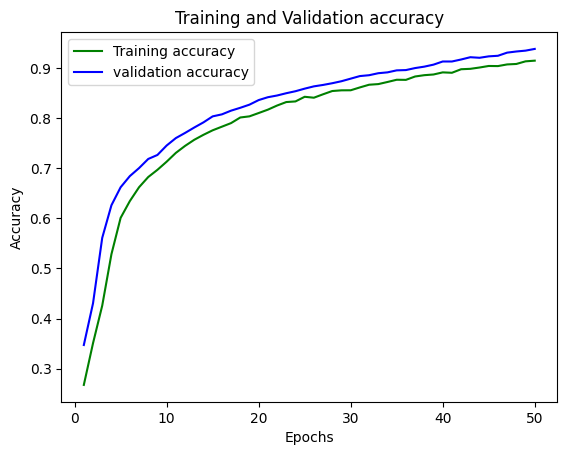

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.plot(epochs, loss_val, 'b', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

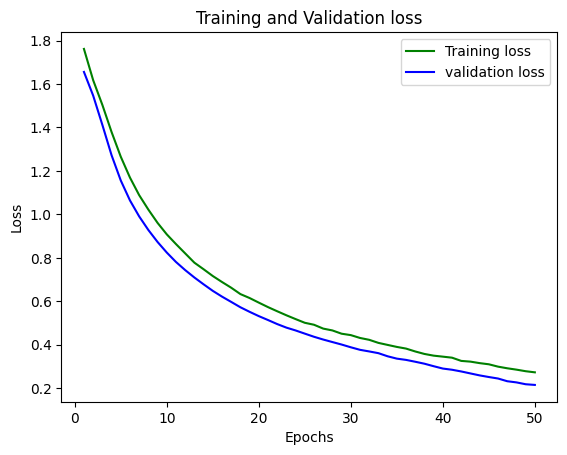

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,EPOCHS + 1)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Save Model

In [ ]:
save_directory = "saved_models"

In [ ]:
model.save_pretrained("/content/drive/MyDrive/distilbert_model")


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/distilbert_model"))


['config.json', 'tf_model.h5']


## Load Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_path = "/content/drive/MyDrive/distilbert_model"


In [ ]:
from transformers import TFDistilBertForSequenceClassification

loaded_model = TFDistilBertForSequenceClassification.from_pretrained(model_path)
print("Model loaded successfully!")



All model checkpoint layers were used when initializing TFDistilBertForSequenceClassification.

All the layers of TFDistilBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/distilbert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


Model loaded successfully!


In [ ]:
from transformers import DistilBertTokenizer

# Define path in Google Drive
tokenizer_path = "/content/drive/MyDrive/distilbert_tokenizer"

# Save the tokenizer
tokenizer.save_pretrained(tokenizer_path)
print(f"Tokenizer saved at {tokenizer_path}")

NameError: name 'tokenizer' is not defined

In [ ]:
from transformers import DistilBertTokenizer
tokenizer_path = "/content/drive/MyDrive/distilbert_tokenizer"
# Load tokenizer from Google Drive
loaded_tokenizer = DistilBertTokenizer.from_pretrained(tokenizer_path)
print("Tokenizer Loaded Successfully!")


Tokenizer Loaded Successfully!


## Testing Predictions

In [ ]:
category_dict = {0: 'Analyse', 1: 'Apply', 2: 'Create', 3: 'Evaluate', 4: 'Remember', 5: 'Understand'}

In [ ]:
# Define the difficulty mapping
difficulty_mapping = {
    'Analyse': 'Medium',
    'Apply': 'Medium',
    'Create': 'Hard',
    'Evaluate': 'Hard',
    'Remember': 'Easy',
    'Understand': 'Easy'
}

In [ ]:
def predict_blooms_with_difficulty(text):
    # Get the original Bloom's Taxonomy prediction
    predict_input = loaded_tokenizer.encode(text,
                                     truncation=True,
                                     padding=True,
                                     return_tensors="tf")

    output = loaded_model(predict_input)[0]
    prediction_value = tf.argmax(output, axis=1).numpy()[0]
    bloom_category = category_dict[prediction_value]

    # Map to difficulty level
    difficulty_level = difficulty_mapping[bloom_category]

    return bloom_category, difficulty_level


In [ ]:
def classify_task(text):
    bloom_level, difficulty = predict_blooms_with_difficulty(text)
    print(f"Text: {text}")
    print(f"Bloom's Taxonomy Level: {bloom_level}")
    print(f"Task Difficulty: {difficulty}")
    return bloom_level, difficulty

In [ ]:
test_text = "what is 2+2"

print(test_text)
classify_task(test_text)

what is 2+2
Text: what is 2+2
Bloom's Taxonomy Level: Analyse
Task Difficulty: Medium


('Analyse', 'Medium')

In [ ]:
import pandas as pd
llm_df=pd.read_csv("/content/lmsys_with_classes.csv")


In [ ]:
llm_df.head()

,rank,rank_stylectrl,model,arena_score,95_pct_ci,votes,organization,license,knowledge_cutoff,url,model_class
0,1,1,Gemini-2.5-Pro-Exp-03-25,1439,+7/-5,9013,Google,Proprietary,Unknown,http://aistudio.google.com/app/prompts/new_cha...,Large (Hard Tasks)
1,2,2,ChatGPT-4o-latest (2025-03-26),1407,+6/-6,8261,OpenAI,Proprietary,Unknown,https://x.com/OpenAI/status/1905331956856050135,Large (Hard Tasks)
2,2,4,Grok-3-Preview-02-24,1402,+5/-3,14849,xAI,Proprietary,Unknown,https://x.ai/blog/grok-3,Large (Hard Tasks)
3,2,2,GPT-4.5-Preview,1398,+5/-6,14520,OpenAI,Proprietary,Unknown,https://openai.com/index/introducing-gpt-4-5/,Large (Hard Tasks)
4,2,4,Gemini-2.5-Flash-Preview-04-17,1392,+10/-13,3325,Google,Proprietary,Unknown,http://aistudio.google.com/app/prompts/new_cha...,Large (Hard Tasks)


In [ ]:
def recommend_llm(prompt, llm_df):
    # Step 1: Classify the task
    bloom_level, difficulty = classify_task(prompt)

    # Step 2: Map difficulty to model class
    if difficulty.lower() == "easy":
        target_class = "Small (Easy Tasks)"
    elif difficulty.lower() == "medium":
        target_class = "Medium (Medium Tasks)"
    else:
        target_class = "Large (Hard Tasks)"

    # Step 3: Filter and sort all models in the target class
    recommended_models = llm_df[llm_df['model_class'] == target_class]
    sorted_models = recommended_models.sort_values(by='arena_score', ascending=False)

    # Step 4: Return result
    print(f"\nPrompt: {prompt}")
    print(f"Bloom Level: {bloom_level} | Difficulty: {difficulty} → LLM Class: {target_class}")
    print(f"\n🔍 {len(sorted_models)} Models Suitable for This Task:\n")
    print(sorted_models[['model', 'arena_score', 'organization']].to_string(index=False))

    return sorted_models


In [ ]:
recommend_llm("solve a python programming problem", llm_df)

Text: solve a python programming problem
Bloom's Taxonomy Level: Create
Task Difficulty: Hard

Prompt: solve a python programming problem
Bloom Level: Create | Difficulty: Hard → LLM Class: Large (Hard Tasks)

🔍 57 Models Suitable for This Task:

                              model  arena_score organization
           Gemini-2.5-Pro-Exp-03-25         1439       Google
     ChatGPT-4o-latest (2025-03-26)         1407       OpenAI
               Grok-3-Preview-02-24         1402          xAI
                    GPT-4.5-Preview         1398       OpenAI
     Gemini-2.5-Flash-Preview-04-17         1392       Google
Gemini-2.0-Flash-Thinking-Exp-01-21         1380       Google
           Gemini-2.0-Pro-Exp-02-05         1380       Google
                   DeepSeek-V3-0324         1372     DeepSeek
                        DeepSeek-R1         1358     DeepSeek
               Gemini-2.0-Flash-001         1354       Google
                      o1-2024-12-17         1350       OpenAI
         

,rank,rank_stylectrl,model,arena_score,95_pct_ci,votes,organization,license,knowledge_cutoff,url,model_class
0,1,1,Gemini-2.5-Pro-Exp-03-25,1439,+7/-5,9013,Google,Proprietary,Unknown,http://aistudio.google.com/app/prompts/new_cha...,Large (Hard Tasks)
1,2,2,ChatGPT-4o-latest (2025-03-26),1407,+6/-6,8261,OpenAI,Proprietary,Unknown,https://x.com/OpenAI/status/1905331956856050135,Large (Hard Tasks)
2,2,4,Grok-3-Preview-02-24,1402,+5/-3,14849,xAI,Proprietary,Unknown,https://x.ai/blog/grok-3,Large (Hard Tasks)
3,2,2,GPT-4.5-Preview,1398,+5/-6,14520,OpenAI,Proprietary,Unknown,https://openai.com/index/introducing-gpt-4-5/,Large (Hard Tasks)
4,2,4,Gemini-2.5-Flash-Preview-04-17,1392,+10/-13,3325,Google,Proprietary,Unknown,http://aistudio.google.com/app/prompts/new_cha...,Large (Hard Tasks)
5,5,9,Gemini-2.0-Flash-Thinking-Exp-01-21,1380,+4/-3,26309,Google,Proprietary,Unknown,https://aistudio.google.com/prompts/new_chat?m...,Large (Hard Tasks)
6,5,5,Gemini-2.0-Pro-Exp-02-05,1380,+5/-4,20127,Google,Proprietary,Unknown,https://aistudio.google.com/prompts/new_chat?m...,Large (Hard Tasks)
7,5,4,DeepSeek-V3-0324,1372,+9/-6,5888,DeepSeek,MIT,Unknown,https://api-docs.deepseek.com/news/news250325,Large (Hard Tasks)
8,9,6,DeepSeek-R1,1358,+4/-5,16077,DeepSeek,MIT,Unknown,https://api-docs.deepseek.com/news/news250120,Large (Hard Tasks)
9,9,14,Gemini-2.0-Flash-001,1354,+3/-4,22201,Google,Proprietary,Unknown,https://aistudio.google.com/app/prompts/new_ch...,Large (Hard Tasks)


In [ ]:
import pickle
pickle.dump(df, open('text.pkl', 'wb'))

NameError: name 'df' is not defined